# Cleanroom CFD Demo 

This notebook uses:

- simulation timeline: `../assets/v2_object_timeline_temperature.csv`
- real ambient reference: `../assets/background_temperature_filtered_resampled.csv`
- room geometry: `../assets/Feynmann room_inked_good.svg`


In [1]:
import os
import sys
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.append("..")
mpl.rcParams["animation.embed_limit"] = 100

from cleanroom_cfd.config import SimulationConfig
from cleanroom_cfd.setup import build_room_setup, build_initial_fields
from cleanroom_cfd.data_pipeline import (
    load_timeline_window,
    build_machine_state,
    build_human_entities_for_time,
    update_machine_entities_for_time,
)
from cleanroom_cfd.simulation import compute_time_step, compute_tau_field, cfd_step
from cleanroom_cfd.analysis import (
    build_base_ambient_mask,
    run_simulation_and_collect_all,
    save_metric_plots,
    build_wall_adjacent_mask
)
from cleanroom_cfd.visualization import animate_simulation
from cleanroom_cfd.entities import Entity

In [2]:
cfg = SimulationConfig()

csv_path = "../assets/v2_object_timeline_temperature.csv"
real_ambient_csv_path = "../assets/background_temperature_filtered_resampled.csv"
svg_path = "../assets/Feynmann room_inked_good.svg"
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)


# Window / experiment settings
table_window_minutes = 360            # example: 6 hours
window_start_timestamp = "2025-04-23 14:29:00"
save_interval_s = 30               


# Simulation settings
cfg.res = 10
cfg.sock_speed = 0.45
cfg.supply_temp = 20.5
cfg.alpha_heat = 2.2e-5

cfg.target_time = table_window_minutes * 60
cfg.frames = int(cfg.target_time / save_interval_s)

print("Target time (hours):", cfg.target_time / 3600.0)
print("Frames:", cfg.frames)

Target time (hours): 6.0
Frames: 720


In [3]:
timeline_data = load_timeline_window(
    csv_path=csv_path,
    table_window_minutes=table_window_minutes,
    window_start_timestamp=window_start_timestamp,
)

print("Window start:", timeline_data["first_ts"])
print("Window end:", timeline_data["end_ts"])
print("Rows in window:", len(timeline_data["df_window"]))
print("Unique timestamps in window:", len(timeline_data["unique_times"]))
print("Labels in window:", sorted(timeline_data["df_window"]["label"].dropna().unique().tolist()))

Window start: 2025-04-23 14:29:00
Window end: 2025-04-23 20:29:00
Rows in window: 2448
Unique timestamps in window: 292
Labels in window: ['Light', 'Machine', 'Person', 'Screen', 'Window']


In [4]:
df_real_ambient = pd.read_csv(real_ambient_csv_path)
df_real_ambient["timestamp"] = pd.to_datetime(df_real_ambient["timestamp"])

window_start = pd.Timestamp(timeline_data["first_ts"])
window_end = pd.Timestamp(timeline_data["end_ts"])

df_real_ambient = (
    df_real_ambient[
        (df_real_ambient["timestamp"] >= window_start) &
        (df_real_ambient["timestamp"] <= window_end)
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Real ambient rows in selected window:", len(df_real_ambient))
print("Real ambient columns:", df_real_ambient.columns.tolist())

real_ambient_out_csv = os.path.join(results_dir, "real_ambient_selected_window.csv")
df_real_ambient.to_csv(real_ambient_out_csv, index=False)
print("Saved:", real_ambient_out_csv)

df_real_ambient.head()

Real ambient rows in selected window: 720
Real ambient columns: ['timestamp', 'ambient_temp_mean_c', 'background_pixels', 'background_confidence', 'date', 'time']
Saved: ../results/real_ambient_selected_window.csv


,timestamp,ambient_temp_mean_c,background_pixels,background_confidence,date,time
0,2025-04-23 14:29:00,22.266619,202207.0,0.853582,2025-04-23,14:29:00
1,2025-04-23 14:29:30,22.913309,197432.0,0.833346,2025-04-23,14:29:30
2,2025-04-23 14:30:00,21.212416,245897.0,0.912093,2025-04-23,14:30:00
3,2025-04-23 14:30:30,21.416397,244250.0,0.906449,2025-04-23,14:30:30
4,2025-04-23 14:31:00,21.178009,246213.0,0.915269,2025-04-23,14:31:00


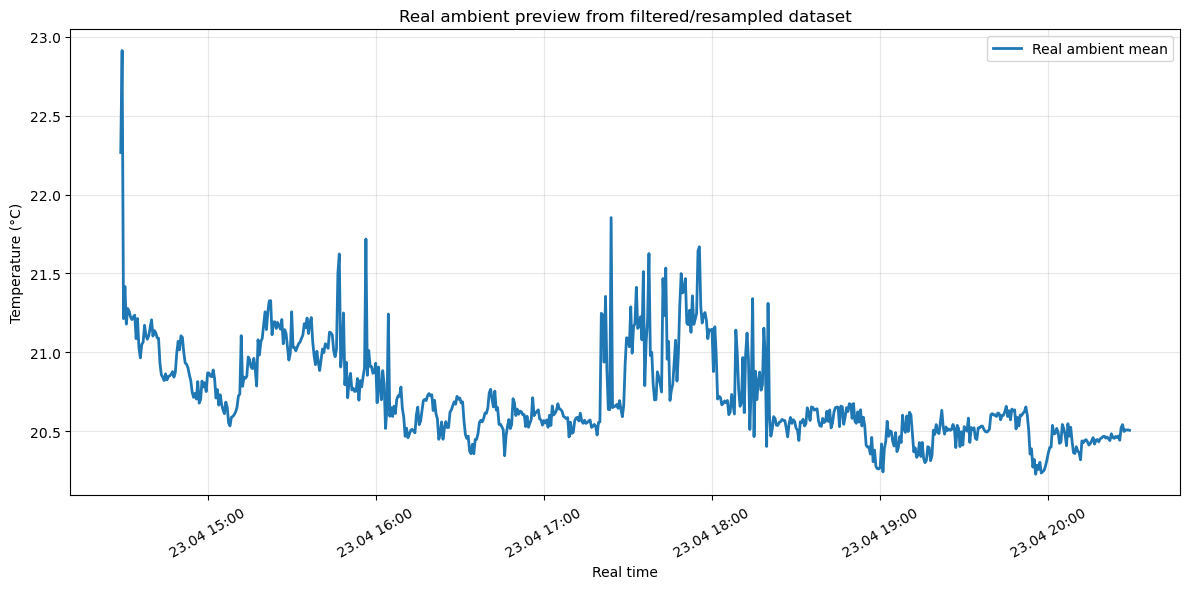

Saved: ../results/real_ambient_preview.png


In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_real_ambient["timestamp"],
    df_real_ambient["ambient_temp_mean_c"],
    label="Real ambient mean",
    linewidth=2
)

plt.xlabel("Real time")
plt.ylabel("Temperature (°C)")
plt.title("Real ambient preview from filtered/resampled dataset")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
plt.xticks(rotation=30)
plt.tight_layout()

preview_plot_path = os.path.join(results_dir, "real_ambient_preview.png")
plt.savefig(preview_plot_path, dpi=150)
plt.show()

print("Saved:", preview_plot_path)

In [6]:
room = build_room_setup(cfg, svg_path)

print("Room size:", room["svg_width_m"], "x", room["svg_height_m"])
print("Grid:", room["grid_w"], "x", room["grid_h"])
print("Sock rows:", room["src_y0"], room["src_y1"])

Room size: 15.0 x 12.0
Grid: 150 x 120
Sock rows: 78 82


In [7]:
base_entities_list = [
    Entity("furniture_passthrough", x_m=2.0, y_m=3.8, width_m=8.8, height_m=2.3, id_name="middle_1"),
    Entity("furniture_passthrough", x_m=10.8, y_m=3.0, width_m=1.0, height_m=3.1, id_name="middle_2"),
    Entity("furniture_passthrough", x_m=1.8, y_m=0.0, width_m=3.6, height_m=1.0, id_name="table_1"),
    Entity("furniture_passthrough", x_m=5.7, y_m=0.0, width_m=3.9, height_m=1.0, id_name="table_2"),
    Entity("furniture_passthrough", x_m=9.8, y_m=0.0, width_m=3.8, height_m=1.0, id_name="table_3"),
]

machine_state = build_machine_state(
    df_window=timeline_data["df_window"],
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    machine_radius_m=0.30,
)

persistent_machine_entities = machine_state["persistent_machine_entities"]
machine_entity_map = machine_state["machine_entity_map"]
machine_temp_lookup = machine_state["machine_temp_lookup"]

persistent_hot_entities = persistent_machine_entities



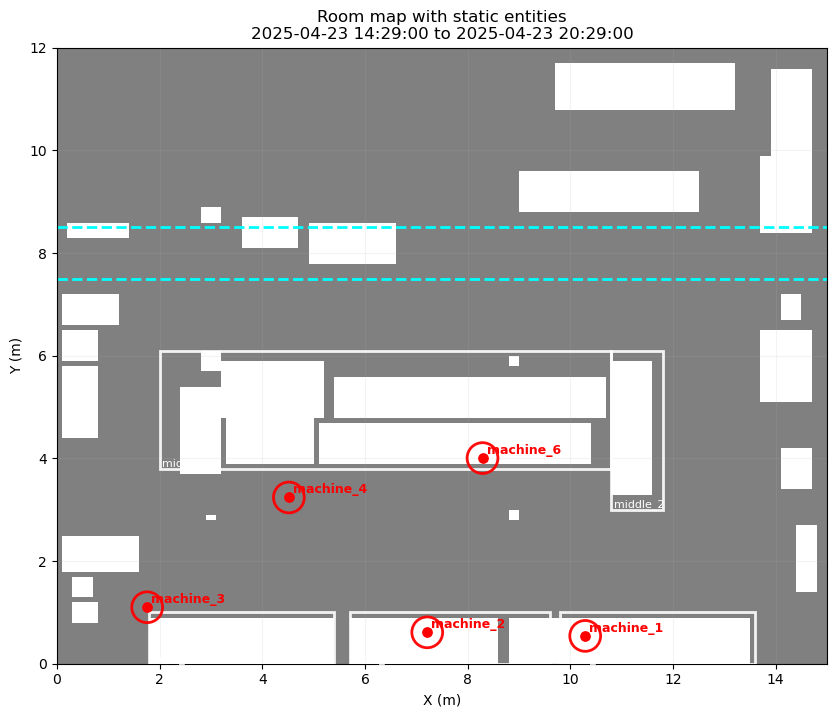

In [8]:
from matplotlib.patches import Circle, Rectangle

plt.figure(figsize=(12, 8))

plt.imshow(
    room["is_obstacle"],
    origin="lower",
    extent=[0, room["svg_width_m"], 0, room["svg_height_m"]],
    cmap="gray",
    alpha=0.5
)

for ent in base_entities_list:
    rect = Rectangle(
        (ent.x, ent.y),
        ent.width,
        ent.height,
        fill=False,
        edgecolor="white",
        linewidth=2,
        alpha=0.9,
        zorder=3
    )
    plt.gca().add_patch(rect)
    plt.text(ent.x + 0.05, ent.y + 0.05, ent.id_name, color="white", fontsize=8)

for ent in persistent_machine_entities:
    cx = ent.x + ent.width / 2
    cy = ent.y + ent.height / 2

    plt.scatter(cx, cy, s=45, c="red", zorder=6)
    plt.gca().add_patch(Circle(
        (cx, cy),
        radius=getattr(ent, "thermal_radius_m", 0.30),
        fill=False,
        edgecolor="red",
        linewidth=2,
        alpha=0.95,
        zorder=5
    ))
    plt.text(cx + 0.08, cy + 0.08, ent.id_name, color="red", fontsize=9, weight="bold")

plt.hlines(
    [cfg.y_sock_m - cfg.sock_thickness_m, cfg.y_sock_m + cfg.sock_thickness_m],
    xmin=0, xmax=room["svg_width_m"],
    colors="cyan",
    linestyles="--",
    linewidth=2
)

plt.xlim(0, room["svg_width_m"])
plt.ylim(0, room["svg_height_m"])
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title(f"Room map with static entities\n{timeline_data['first_ts']} to {timeline_data['end_ts']}")
plt.grid(alpha=0.15)
plt.show()

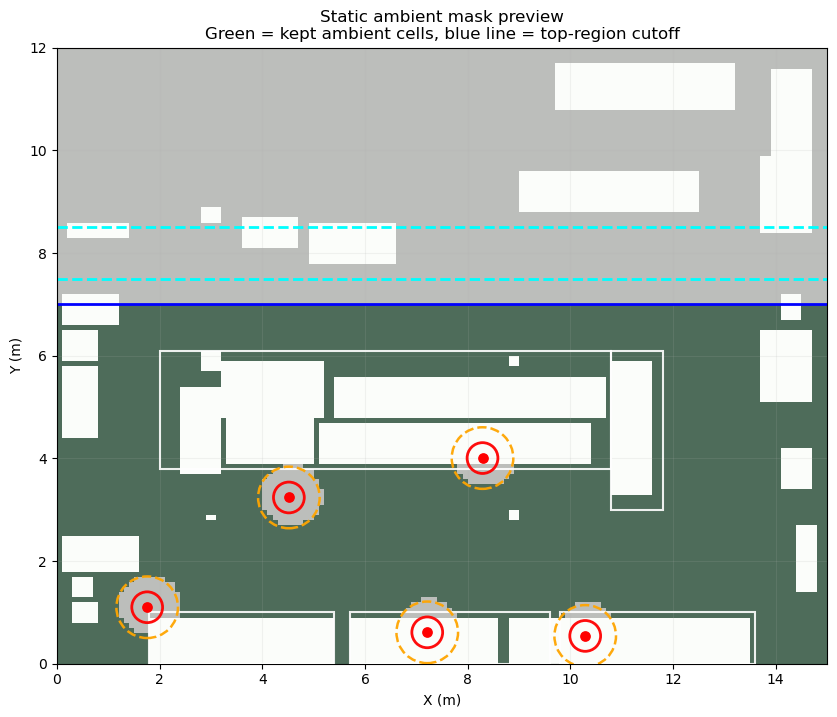

Ambient cells kept: 7025
Total cells: 18000
Fraction kept: 0.3902777777777778


In [9]:
from matplotlib.patches import Circle, Rectangle

exclude_above_y_m = 7.0   # change here if you want 7.5, 7.2, etc.

base_ambient_mask = build_base_ambient_mask(
    is_obstacle=room["is_obstacle"],
    persistent_hot_entities=persistent_hot_entities,
    res=cfg.res,
    machine_exclusion_radius_m=0.60,
    exclude_above_y_m=exclude_above_y_m,
)

wall_adjacent_mask = build_wall_adjacent_mask(
    is_obstacle=room["is_obstacle"],
    furniture_entities=base_entities_list,
    persistent_hot_entities=persistent_hot_entities,
    res=cfg.res,
    layers=1
)

plt.figure(figsize=(12, 8))

plt.imshow(
    room["is_obstacle"],
    origin="lower",
    extent=[0, room["svg_width_m"], 0, room["svg_height_m"]],
    cmap="gray",
    alpha=0.45
)

plt.imshow(
    base_ambient_mask.astype(float),
    origin="lower",
    extent=[0, room["svg_width_m"], 0, room["svg_height_m"]],
    cmap="Greens",
    alpha=0.45,
    vmin=0,
    vmax=1
)

for ent in base_entities_list:
    rect = Rectangle(
        (ent.x, ent.y),
        ent.width,
        ent.height,
        fill=False,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.9,
        zorder=3
    )
    plt.gca().add_patch(rect)

for ent in persistent_machine_entities:
    cx = ent.x + ent.width / 2
    cy = ent.y + ent.height / 2

    plt.scatter(cx, cy, s=45, c="red", zorder=6)

    plt.gca().add_patch(Circle(
        (cx, cy),
        radius=getattr(ent, "thermal_radius_m", 0.30),
        fill=False,
        edgecolor="red",
        linewidth=2,
        alpha=0.95,
        zorder=5
    ))

    plt.gca().add_patch(Circle(
        (cx, cy),
        radius=0.60,
        fill=False,
        edgecolor="orange",
        linewidth=1.8,
        linestyle="--",
        alpha=0.95,
        zorder=4
    ))

plt.hlines(
    [cfg.y_sock_m - cfg.sock_thickness_m, cfg.y_sock_m + cfg.sock_thickness_m],
    xmin=0, xmax=room["svg_width_m"],
    colors="cyan",
    linestyles="--",
    linewidth=2
)

plt.hlines(
    exclude_above_y_m,
    xmin=0, xmax=room["svg_width_m"],
    colors="blue",
    linestyles="-",
    linewidth=2
)

plt.xlim(0, room["svg_width_m"])
plt.ylim(0, room["svg_height_m"])
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Static ambient mask preview\nGreen = kept ambient cells, blue line = top-region cutoff")
plt.grid(alpha=0.15)
plt.show()

print("Ambient cells kept:", int(base_ambient_mask.sum()))
print("Total cells:", base_ambient_mask.size)
print("Fraction kept:", base_ambient_mask.sum() / base_ambient_mask.size)

In [22]:
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

dt = compute_time_step(room["dx"], cfg.sock_speed, cfg.alpha_heat, cfg.nu_eff)

tau_field = compute_tau_field(
    (room["grid_h"], room["grid_w"]),
    room["src_y0"],
    room["src_y1"],
    room["is_obstacle"],
    base_entities_list + persistent_hot_entities,
    cfg.res,
    tau_min=300, #100
    tau_max=1200, # 400
)

substeps_per_frame = int(save_interval_s / dt)

print("dt =", dt)
print("frames =", cfg.frames)
print("save interval (s) =", save_interval_s)
print("substeps_per_frame =", substeps_per_frame)
print("total simulated time represented (hours) =", cfg.frames * save_interval_s / 3600.0)


dt = 0.06666666666666667
frames = 720
save interval (s) = 30
substeps_per_frame = 450
total simulated time represented (hours) = 6.0


In [23]:
sim_time_state = {"t": 0.0}
dynamic_entities_state = {"humans": []}
_debug_printed = {"done": False}

def step_fn(T, tracer, u, v, p):
    
    update_machine_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        machine_entity_map=machine_entity_map,
        machine_temp_lookup=machine_temp_lookup,
        grace_period_minutes=3,
    )

    
    human_entities = build_human_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        rows_by_time=timeline_data["rows_by_time"],
        svg_width_m=room["svg_width_m"],
        svg_height_m=room["svg_height_m"],
    )

    dynamic_entities_state["humans"] = human_entities

    entities_list = base_entities_list + persistent_machine_entities + human_entities

    out = cfd_step(
        T, tracer, u, v, p,
        dx=room["dx"],
        dt=dt,
        entities_list=entities_list,
        is_obstacle=room["is_obstacle"],
        res=cfg.res,
        src_y0=room["src_y0"],
        src_y1=room["src_y1"],
        hs_x=room["hs_x"],
        hs_y=room["hs_y"],
        bubble_r=cfg.bubble_r,
        alpha_heat=cfg.alpha_heat,
        nu_eff=cfg.nu_eff,
        rho=cfg.rho,
        beta_b=cfg.beta_b,
        g=cfg.g,
        T_ref=cfg.T_ref,
        sock_speed=cfg.sock_speed,
        supply_temp=cfg.supply_temp,
        smoke_diff=cfg.smoke_diff,
        pressure_iters=cfg.pressure_iters,
        max_speed=cfg.max_speed,
        tau_field=tau_field,
    )
    # if not _debug_printed["done"]:
    #     T_out = out[0]  # primer elemento es T_next
    #     for ent in persistent_machine_entities:
    #         if ent.is_active:
    #             mask = ent.get_thermal_mask(cfg.res, room["grid_h"], room["grid_w"])
    #             print(f"{ent.id_name}: celdas={mask.sum()}, T_mean={T_out[mask].mean():.2f}, T_max={T_out[mask].max():.2f}")
    #     _debug_printed["done"] = True


    sim_time_state["t"] += dt
    return out

In [25]:
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

sim_time_state = {"t": 0.0}
dynamic_entities_state = {"humans": []}
persistent_hot_entities = persistent_machine_entities

df_all_metrics, final_state = run_simulation_and_collect_all(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    dt=dt,
    room=room,
    cfg=cfg,
    is_obstacle=room["is_obstacle"],
    persistent_hot_entities=persistent_hot_entities,
    persistent_machine_entities=persistent_machine_entities,
    res=cfg.res,
    dynamic_entities_state=dynamic_entities_state,
    real_start_timestamp=timeline_data["first_ts"],
    machine_exclusion_radius_m=0.60,
    human_exclusion_radius_m=0.30,
    surround_pad_cells=3,
    use_circular_machine_metrics=True,
    default_machine_radius_m=0.30,
    surround_outer_radius_m=0.60,
    exclude_region_above_sock=False,
    fixed_ambient_top_cutoff_m=7.0,
    wall_adjacent_mask=wall_adjacent_mask,
)

all_metrics_csv = os.path.join(results_dir, "all_metrics.csv")
df_all_metrics.to_csv(all_metrics_csv, index=False)

save_metric_plots(df_all_metrics, results_dir)

print("Saved unified metrics to:", all_metrics_csv)
df_all_metrics.head()

Saved unified metrics to: ../results/all_metrics.csv


,room_avg_temp,room_max_temp,room_min_temp,room_std_temp,room_avg_speed,room_max_speed,machine_machine_1_box_temp,machine_machine_1_surround_temp,machine_machine_2_box_temp,machine_machine_2_surround_temp,...,sim_ambient_mean,sim_ambient_median,ambient_cell_count,human_count,sim_wall_temp_mean,sim_wall_temp_median,frame,sim_time_s,sim_time_min,real_datetime
0,20.844215,30.009953,20.676632,0.617186,0.0,0.0,NaN,20.822764,26.880054,20.995593,...,20.788493,20.788540,6884,5,20.807149,20.786520,1,30.0,0.5,2025-04-23 14:29:30
1,20.834763,30.009953,20.660284,0.629917,0.0,0.0,NaN,20.846864,26.880054,21.178699,...,20.777762,20.777749,6884,5,20.802430,20.773828,2,60.0,1.0,2025-04-23 14:30:00
2,20.824408,30.009953,20.645648,0.638439,0.0,0.0,NaN,20.869714,26.880054,21.321740,...,20.767444,20.767250,6884,5,20.795579,20.761639,3,90.0,1.5,2025-04-23 14:30:30
3,20.814185,30.009953,20.632485,0.645445,0.0,0.0,NaN,20.890948,26.880054,21.439604,...,20.757699,20.757159,6884,5,20.788223,20.749949,4,120.0,2.0,2025-04-23 14:31:00
4,20.804371,30.009953,20.620601,0.651689,0.0,0.0,NaN,20.910553,26.880054,21.541232,...,20.748540,20.747659,6884,5,20.780887,20.738809,5,150.0,2.5,2025-04-23 14:31:30


In [26]:
box_cols = [c for c in df_all_metrics.columns if c.endswith("_box_temp")]
x = pd.to_datetime(df_all_metrics["real_datetime"])

plt.figure(figsize=(12, 7))
for col in box_cols:
    plt.plot(x, df_all_metrics[col], label=col)

plt.xlabel("Real time")
plt.ylabel("Temperature (°C)")
plt.title("Machine hotspot temperatures over time")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()

machine_plot_path = os.path.join(results_dir, "machine_box_temperatures.png")
plt.savefig(machine_plot_path, dpi=150)
plt.close()

print("Saved machine plot to:", machine_plot_path)

Saved machine plot to: ../results/machine_box_temperatures.png


In [27]:
x = pd.to_datetime(df_all_metrics["real_datetime"])

plt.figure(figsize=(10, 6))
plt.plot(x, df_all_metrics["sim_ambient_median"], label="Sim ambient median")
plt.plot(x, df_all_metrics["sim_ambient_mean"], label="Sim ambient mean", alpha=0.8)

plt.xlabel("Real time")
plt.ylabel("Temperature (°C)")
plt.title("Simulated ambient temperature over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()

sim_ambient_plot_path = os.path.join(results_dir, "simulated_ambient_temperature.png")
plt.savefig(sim_ambient_plot_path, dpi=150)
plt.close()

print("Saved simulated ambient plot to:", sim_ambient_plot_path)

Saved simulated ambient plot to: ../results/simulated_ambient_temperature.png


Saved: ../results/ambient_comparison_new_real_dataset.csv


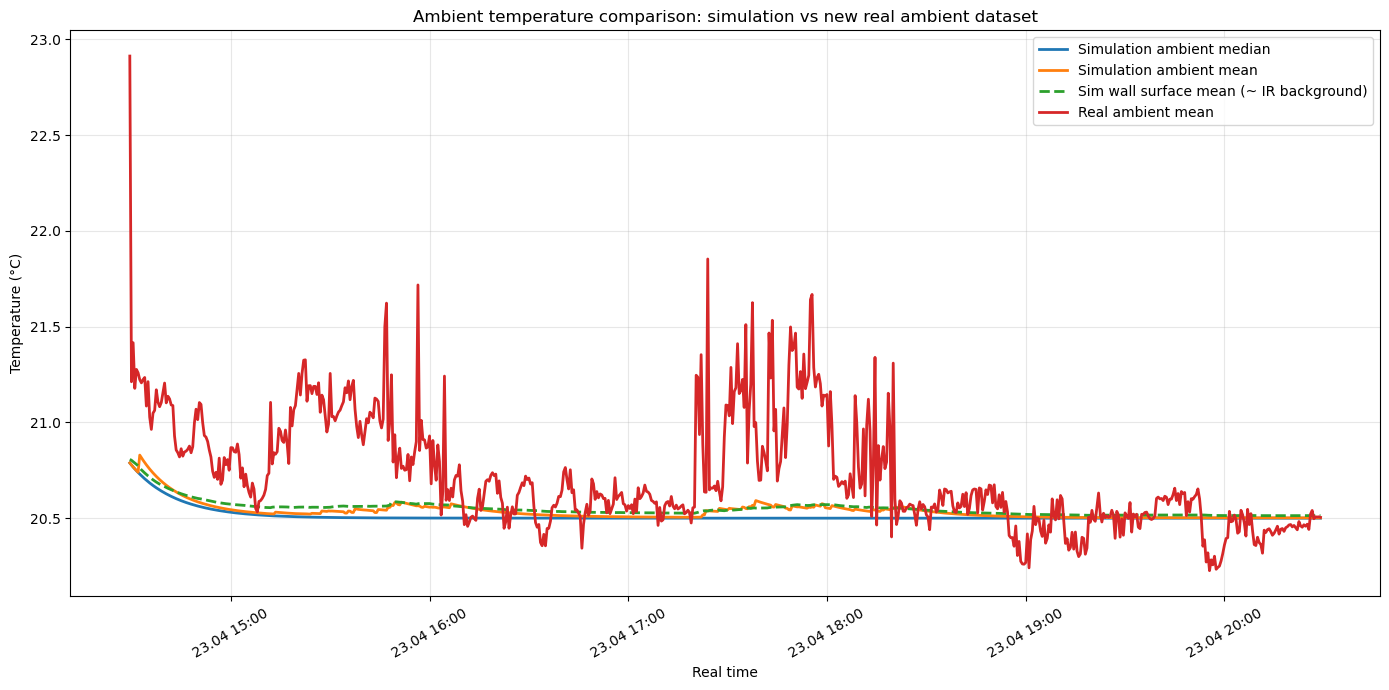

Saved: ../results/ambient_temperature_comparison_new_real_dataset.png


In [28]:
sim_ambient = df_all_metrics.copy()
sim_ambient["real_datetime"] = pd.to_datetime(sim_ambient["real_datetime"])
sim_ambient = sim_ambient.sort_values("real_datetime").reset_index(drop=True)

real_ambient = df_real_ambient.copy()
real_ambient["timestamp"] = pd.to_datetime(real_ambient["timestamp"])
real_ambient = real_ambient.sort_values("timestamp").reset_index(drop=True)

window_start = pd.Timestamp(timeline_data["first_ts"])
window_end = pd.Timestamp(timeline_data["end_ts"])

sim_ambient = sim_ambient[
    (sim_ambient["real_datetime"] >= window_start) &
    (sim_ambient["real_datetime"] <= window_end)
].copy()

real_ambient = real_ambient[
    (real_ambient["timestamp"] >= window_start) &
    (real_ambient["timestamp"] <= window_end)
].copy()

df_compare = pd.merge_asof(
    sim_ambient.sort_values("real_datetime"),
    real_ambient.sort_values("timestamp"),
    left_on="real_datetime",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("2min")
)

compare_csv = os.path.join(results_dir, "ambient_comparison_new_real_dataset.csv")
df_compare.to_csv(compare_csv, index=False)
print("Saved:", compare_csv)

plt.figure(figsize=(14, 7))

plt.plot(
    df_compare["real_datetime"],
    df_compare["sim_ambient_median"],
    label="Simulation ambient median",
    linewidth=2
)

plt.plot(
    df_compare["real_datetime"],
    df_compare["sim_ambient_mean"],
    label="Simulation ambient mean",
    linewidth=2
)

plt.plot(
    df_compare["real_datetime"],
    df_compare["sim_wall_temp_mean"],
    label="Sim wall surface mean (~ IR background)",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    df_compare["real_datetime"],
    df_compare["ambient_temp_mean_c"],
    label="Real ambient mean",
    linewidth=2
)

plt.xlabel("Real time")
plt.ylabel("Temperature (°C)")
plt.title("Ambient temperature comparison: simulation vs new real ambient dataset")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
plt.xticks(rotation=30)
plt.tight_layout()

comparison_plot_path = os.path.join(results_dir, "ambient_temperature_comparison_new_real_dataset.png")
plt.savefig(comparison_plot_path, dpi=150)
plt.show()

print("Saved:", comparison_plot_path)

In [ ]:
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

sim_time_state = {"t": 0.0}
dynamic_entities_state = {"humans": []}

gif_path = os.path.join(results_dir, "simulation.gif")

anim = animate_simulation(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    is_obstacle=room["is_obstacle"],
    y_sock_m=cfg.y_sock_m,
    sock_thickness_m=cfg.sock_thickness_m,
    hs_x_m=cfg.hotspot_x_m,
    hs_y_m=cfg.hotspot_y_m,
    v_sock_target=cfg.sock_speed,
    T_supply=cfg.supply_temp,
    dt=dt,
    entities_list=base_entities_list + persistent_machine_entities,
    real_start_timestamp=timeline_data["first_ts"],
    dynamic_entities_state=dynamic_entities_state,
    save_gif_path=gif_path,
    gif_fps=8,
    show_inline=False,
)

print("Saved GIF to:", gif_path)